In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
gs = pd.read_csv('/content/drive/MyDrive/S2_Polygon_MeanBands_2025.csv')

In [3]:
gs = gs[~gs['Class'].isin(['Industrial','Cleared'])]

In [4]:
gs['NDVI'] = (gs['B8'] - gs['B4']) / (gs['B8'] + gs['B4'])
gs['NDVI'] = np.nan_to_num(gs['NDVI'], nan=0.0, posinf=0.0, neginf=0.0)

print("NDVI calculated and added to the 'gs' DataFrame.")
print(gs[['B8', 'B4', 'NDVI']].head())

NDVI calculated and added to the 'gs' DataFrame.
            B8          B4      NDVI
1  2215.525145  975.422957  0.388631
2  2147.578862  922.346155  0.399108
3  1890.829263  781.990991  0.414857
4  1904.532715  623.130272  0.506951
5  1884.168631  647.646039  0.488394


In [5]:
feature_columns = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI']
X = gs[feature_columns]
y = gs['Class']

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete:")
print(f"Original features shape: {X.shape}")
print(f"Encoded target shape: {y_encoded.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preparation complete:
Original features shape: (171, 7)
Encoded target shape: (171,)
X_train_scaled shape: (136, 7)
X_test_scaled shape: (35, 7)
y_train shape: (136,)
y_test shape: (35,)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]  # Increased max_iter for convergence
}

# Create a Logistic Regression model instance
lr = LogisticRegression(random_state=42)

# Ensure X_train_scaled does not contain NaNs before fitting
X_train_scaled_cleaned = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Initialize GridSearchCV
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the cleaned scaled training data
grid_search.fit(X_train_scaled_cleaned, y_train)

# Print the best parameters found
print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)

Best parameters found by GridSearchCV:
{'C': 100, 'max_iter': 1000, 'solver': 'lbfgs'}


In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Retrieve the best estimator
best_lr_model = grid_search.best_estimator_

# 2. Ensure X_test_scaled does not contain NaNs
X_test_scaled_cleaned = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# 3. Make predictions on the cleaned test data
y_pred = best_lr_model.predict(X_test_scaled_cleaned)

# 4. Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 5. Print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 6. Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")


Classification Report:
                   precision    recall  f1-score   support

Green_residential       0.88      0.70      0.78        10
         Parkland       0.78      0.88      0.82         8
            Urban       0.89      1.00      0.94         8
            Water       1.00      1.00      1.00         9

         accuracy                           0.89        35
        macro avg       0.89      0.89      0.89        35
     weighted avg       0.89      0.89      0.88        35


Confusion Matrix:
[[7 2 1 0]
 [1 7 0 0]
 [0 0 8 0]
 [0 0 0 9]]

Accuracy Score: 0.8857


In [8]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9]
}

print("XGBoost parameter grid defined:")
print(param_grid_xgb)

XGBoost parameter grid defined:
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.7, 0.8, 0.9]}


In [9]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Initialize the XGBoost classifier
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)

# Initialize GridSearchCV with the XGBoost model and parameter grid
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled and cleaned training data
grid_search_xgb.fit(X_train_scaled_cleaned, y_train)

# Print the best parameters found by GridSearchCV
print("Best parameters found by GridSearchCV for XGBoost:")
print(grid_search_xgb.best_params_)

Best parameters found by GridSearchCV for XGBoost:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Retrieve the best estimator
best_xgb_model = grid_search_xgb.best_estimator_

# 2. Make predictions on the cleaned test data
y_pred_xgb = best_xgb_model.predict(X_test_scaled_cleaned)

# 3. Print classification report
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))

# 4. Print confusion matrix
print("\nConfusion Matrix for XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))

# 5. Calculate and print accuracy score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nAccuracy Score for XGBoost: {accuracy_xgb:.4f}")


Classification Report for XGBoost:
                   precision    recall  f1-score   support

Green_residential       0.83      1.00      0.91        10
         Parkland       1.00      0.75      0.86         8
            Urban       1.00      1.00      1.00         8
            Water       1.00      1.00      1.00         9

         accuracy                           0.94        35
        macro avg       0.96      0.94      0.94        35
     weighted avg       0.95      0.94      0.94        35


Confusion Matrix for XGBoost:
[[10  0  0  0]
 [ 2  6  0  0]
 [ 0  0  8  0]
 [ 0  0  0  9]]

Accuracy Score for XGBoost: 0.9429


In [11]:
''' JavaScript run in GEE for the Singapore raster
// 1. Coastal-complete geometry (no political boundary dependency)
var sg = ee.Geometry.Rectangle([103.55, 1.15, 104.10, 1.50]);

// 2. Cloud + shadow mask (keep water)
function maskS2sr(img) {
  var scl = img.select('SCL');
  var mask = scl.neq(3)
    .and(scl.neq(8))
    .and(scl.neq(9))
    .and(scl.neq(10))
    .and(scl.neq(11));
  return img.updateMask(mask);
}

var start = '2025-01-01';
var end   = '2025-12-31';

var s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
  .filterBounds(sg)
  .filterDate(start, end)
  .map(maskS2sr)
  .reduce(ee.Reducer.percentile([25]))   // better for coastlines
  .clip(sg);

// Rename bands after percentile reducer
var bands = [
  'B2_p25','B3_p25','B4_p25',
  'B8_p25','B11_p25','B12_p25'
];

var x = s2.select(bands).rename(['B2','B3','B4','B8','B11','B12']);

Export.image.toDrive({
  image: x,
  description: 'SG_coastal_complete_2025',
  region: sg,
  scale: 10,
  maxPixels: 1e13,
  fileFormat: 'GeoTIFF',
  formatOptions: {cloudOptimized: true}
});

});
'''

" JavaScript run in GEE for the Singapore raster\n// 1. Coastal-complete geometry (no political boundary dependency)\nvar sg = ee.Geometry.Rectangle([103.55, 1.15, 104.10, 1.50]);\n\n// 2. Cloud + shadow mask (keep water)\nfunction maskS2sr(img) {\n  var scl = img.select('SCL');\n  var mask = scl.neq(3)\n    .and(scl.neq(8))\n    .and(scl.neq(9))\n    .and(scl.neq(10))\n    .and(scl.neq(11));\n  return img.updateMask(mask);\n}\n\nvar start = '2025-01-01';\nvar end   = '2025-12-31';\n\nvar s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')\n  .filterBounds(sg)\n  .filterDate(start, end)\n  .map(maskS2sr)\n  .reduce(ee.Reducer.percentile([25]))   // better for coastlines\n  .clip(sg);\n\n// Rename bands after percentile reducer\nvar bands = [\n  'B2_p25','B3_p25','B4_p25',\n  'B8_p25','B11_p25','B12_p25'\n];\n\nvar x = s2.select(bands).rename(['B2','B3','B4','B8','B11','B12']);\n\nExport.image.toDrive({\n  image: x,\n  description: 'SG_coastal_complete_2025',\n  region: sg,\n  scale:

In [12]:
singapore_path_primary = '/content/drive/MyDrive/SG_S2SR_bandstack_2025-01-01_2025-12-31.tif'
singapore_path_fallback = '/content/drive/MyDrive/SG_S2SR_bandstack_2025-01-01_2025-12-31.tif'

singapore_src = None # Initialize singapore_src

try:
    singapore_src = rasterio.open(singapore_path_primary)
    print(f"Successfully loaded Singapore TIFF image from: {singapore_path_primary}")
except rasterio.errors.RasterioIOError as e:
    print(f"Failed to load primary Singapore TIFF image from {singapore_path_primary}: {e}")
    print(f"Attempting to load fallback path: {singapore_path_fallback}")
    try:
        singapore_src = rasterio.open(singapore_path_fallback)
        print(f"Successfully loaded Singapore TIFF image from fallback path: {singapore_path_fallback}")
    except rasterio.errors.RasterioIOError as e_fallback:
        print(f"Failed to load fallback Singapore TIFF image from {singapore_path_fallback}: {e_fallback}")
        print("Neither Singapore TIFF file could be loaded. Please ensure the paths are correct and the files exist.")
        singapore_src = None

if singapore_src is not None:
    print(f"\nOpened dataset information:\nBounds: {singapore_src.bounds}\nResolution: {singapore_src.res}\nNumber of bands: {singapore_src.count}")

Successfully loaded Singapore TIFF image from: /content/drive/MyDrive/SG_S2SR_bandstack_2025-01-01_2025-12-31.tif

Opened dataset information:
Bounds: BoundingBox(left=103.63827500275555, bottom=1.164036945162076, right=104.09012759066766, top=1.4713506038593642)
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Number of bands: 6


In [13]:
if singapore_src is not None:
    # Extract B4 (Red), B3 (Green), B2 (Blue) bands
    # Based on the GEE script, the order is B2, B3, B4, B8, B11, B12.
    # So, B2 is band 1, B3 is band 2, B4 is band 3.
    b2_sg = singapore_src.read(1)
    b3_sg = singapore_src.read(2)
    b4_sg = singapore_src.read(3)

    # Get image dimensions
    height_sg, width_sg = b2_sg.shape

    # Normalize bands for visualization (0-1 range)
    # Clip outliers and scale to 0-1 range
    def normalize_band(band):
        # Clip values to the 2nd and 98th percentile to handle outliers
        p2, p98 = np.percentile(band[band > 0], (2, 98)) # Exclude 0s if they represent no data
        normalized_band = np.clip(band, p2, p98)
        # Scale to 0-1
        normalized_band = (normalized_band - p2) / (p98 - p2)
        return normalized_band

    b2_sg_norm = normalize_band(b2_sg)
    b3_sg_norm = normalize_band(b3_sg)
    b4_sg_norm = normalize_band(b4_sg)

    print(f"Extracted and normalized B2, B3, B4 bands for Singapore image.")
    print(f"Normalized B2 min: {b2_sg_norm.min():.4f}, max: {b2_sg_norm.max():.4f}")
    print(f"Normalized B3 min: {b3_sg_norm.min():.4f}, max: {b3_sg_norm.max():.4f}")
    print(f"Normalized B4 min: {b4_sg_norm.min():.4f}, max: {b4_sg_norm.max():.4f}")
else:
    print("Cannot extract bands, Singapore TIFF source is not available.")

Extracted and normalized B2, B3, B4 bands for Singapore image.
Normalized B2 min: nan, max: nan
Normalized B3 min: nan, max: nan
Normalized B4 min: nan, max: nan


In [14]:
if singapore_src is not None:
    # Extract B4 (Red), B3 (Green), B2 (Blue) bands
    # Based on the GEE script, the order is B2, B3, B4, B8, B11, B12.
    # So, B2 is band 1, B3 is band 2, B4 is band 3.
    b2_sg = singapore_src.read(1)
    b3_sg = singapore_src.read(2)
    b4_sg = singapore_src.read(3)

    # Get image dimensions
    height_sg, width_sg = b2_sg.shape

    # Normalize bands for visualization (0-1 range)
    # Clip outliers and scale to 0-1 range
    def normalize_band(band):
        # Filter out NaN values and values <= 0, as these often represent nodata or irrelevant background
        valid_pixels = band[(~np.isnan(band)) & (band > 0)]

        if valid_pixels.size == 0:
            # If no valid pixels, return an array of zeros
            return np.zeros_like(band, dtype=float)

        # Clip values to the 2nd and 98th percentile to handle outliers
        p2, p98 = np.percentile(valid_pixels, (2, 98))

        if p98 == p2: # Avoid division by zero if all valid pixels have the same value
            return np.zeros_like(band, dtype=float) if p2 == 0 else np.ones_like(band, dtype=float) * (1 if p2 > 0 else 0)

        normalized_band = np.clip(band, p2, p98)
        # Scale to 0-1
        normalized_band = (normalized_band - p2) / (p98 - p2)

        # Replace any remaining NaNs (from pixels that were not >0 or were nodata) with 0
        normalized_band = np.nan_to_num(normalized_band, nan=0.0)
        return normalized_band

    b2_sg_norm = normalize_band(b2_sg)
    b3_sg_norm = normalize_band(b3_sg)
    b4_sg_norm = normalize_band(b4_sg)

    print(f"Extracted and normalized B2, B3, B4 bands for Singapore image.")
    print(f"Normalized B2 min: {b2_sg_norm.min():.4f}, max: {b2_sg_norm.max():.4f}")
    print(f"Normalized B3 min: {b3_sg_norm.min():.4f}, max: {b3_sg_norm.max():.4f}")
    print(f"Normalized B4 min: {b4_sg_norm.min():.4f}, max: {b4_sg_norm.max():.4f}")
else:
    print("Cannot extract bands, Singapore TIFF source is not available.")

Extracted and normalized B2, B3, B4 bands for Singapore image.
Normalized B2 min: 0.0000, max: 1.0000
Normalized B3 min: 0.0000, max: 1.0000
Normalized B4 min: 0.0000, max: 1.0000


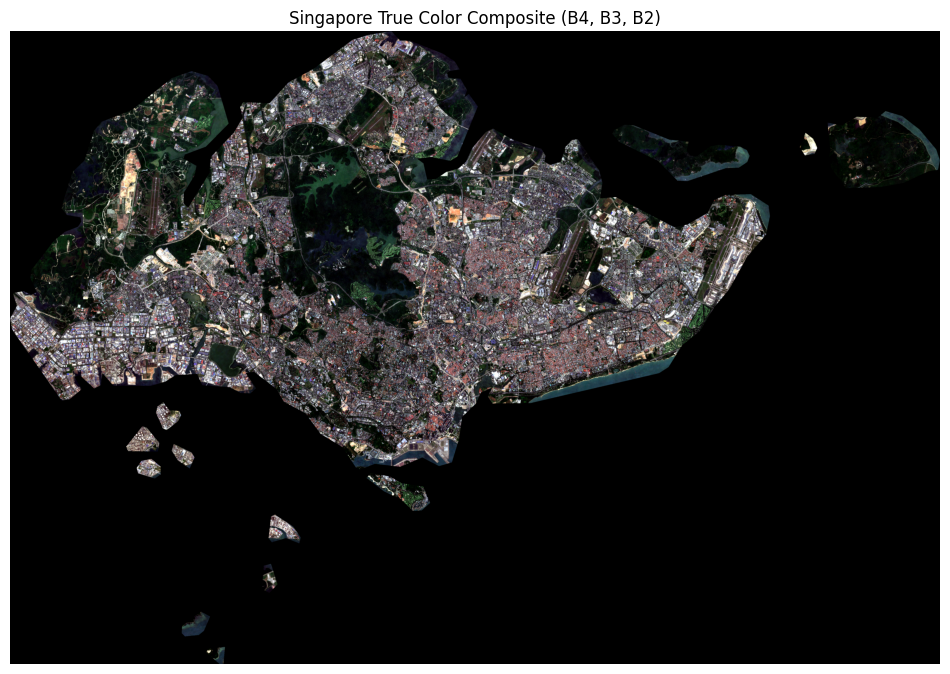

Singapore true color composite image displayed.


In [15]:
if singapore_src is not None:
    # Stack the normalized bands to create an RGB image for visualization
    # The order for a true-color composite is Red (B4), Green (B3), Blue (B2)
    rgb_singapore = np.dstack((b4_sg_norm, b3_sg_norm, b2_sg_norm))

    # Display the RGB composite image
    plt.figure(figsize=(12, 12))
    plt.imshow(rgb_singapore)
    plt.title('Singapore True Color Composite (B4, B3, B2)')
    plt.axis('off') # Hide axes for a cleaner image display
    plt.show()

    print("Singapore true color composite image displayed.")
else:
    print("Cannot display RGB composite, Singapore TIFF source is not available.")

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import rasterio

if singapore_src is not None and 'singapore_classified_image' in locals() and 'label_encoder' in locals():
    # Define approximate geographic bounds for the TUAS region (adjust as needed)
    # These bounds are chosen to highlight a typical area identified as Tuas.
    tuas_lon_min, tuas_lat_min = 103.63, 1.28
    tuas_lon_max, tuas_lat_max = 103.75, 1.40

    # Get the window (pixel coordinates) corresponding to the TUAS geographic bounds
    # Ensure the bounds are in the same CRS as the source raster
    try:
        # rasterio.window expects (left, bottom, right, top) for bounds
        tuas_window = singapore_src.window(tuas_lon_min, tuas_lat_min, tuas_lon_max, tuas_lat_max)
    except Exception as e:
        print(f"Error calculating window for TUAS bounds: {e}")
        print("Please check if TUAS bounds are within the raster's extent or if CRS conversion is needed.")
        tuas_window = None

    if tuas_window is not None:
        # Extract the TUAS region from the classified image
        # Note: rasterio.window returns a tuple of slice objects (row_slice, col_slice)
        # We need to explicitly convert to integer indices for numpy slicing.
        row_start = int(tuas_window.row_off)
        row_end = int(tuas_window.row_off + tuas_window.height)
        col_start = int(tuas_window.col_off)
        col_end = int(tuas_window.col_off + tuas_window.width)

        # Ensure indices are within array bounds
        height_sg, width_sg = singapore_classified_image.shape # Get dimensions from the classified image
        row_start = max(0, row_start)
        row_end = min(height_sg, row_end)
        col_start = max(0, col_start)
        col_end = min(width_sg, col_end)

        tuas_classified_image = singapore_classified_image[row_start:row_end, col_start:col_end]

        # Get the unique class labels from the TUAS predictions
        unique_classes_tuas = np.unique(tuas_classified_image)

        # Create a color map for visualization, consistent with the full image
        base_cmap_sg = plt.colormaps['tab20']
        # Use full set of classes from label_encoder to ensure consistent color mapping across all plots
        colors_sg = base_cmap_sg(np.linspace(0, 1, len(label_encoder.classes_)))
        cmap_sg = mcolors.ListedColormap(colors_sg)

        # Create a mapping from class names to integer labels for visualization purposes
        class_to_int_sg = {cls: i for i, cls in enumerate(label_encoder.classes_)}

        # Convert the string labels in the classified TUAS image to integers for the colormap
        tuas_classified_image_int = np.vectorize(class_to_int_sg.get)(tuas_classified_image)

        plt.figure(figsize=(10, 10))
        plt.imshow(tuas_classified_image_int, cmap=cmap_sg)
        plt.title('TUAS Land Cover Classification (XGBoost)')
        plt.xlabel('Pixel Column')
        plt.ylabel('Pixel Row')

        # Create a custom legend using mpatches.Patch for only present classes in the TUAS view
        patches_tuas = [mpatches.Patch(color=colors_sg[class_to_int_sg[cls]], label=cls) for cls in unique_classes_tuas]
        plt.legend(handles=patches_tuas, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

        plt.tight_layout()
        plt.show()

        print("Classified TUAS region visualized.")
    else:
        print("Failed to define pixel window for TUAS region.")
else:
    print("Cannot visualize classified TUAS region. Data or model components are missing.")

Cannot visualize classified TUAS region. Data or model components are missing.


In [17]:
if singapore_src is not None:
    # Read all required bands. The GEE export script defined the order as ['B2','B3','B4','B8','B11','B12'].
    # In rasterio, bands are 1-indexed.
    b2_sg = singapore_src.read(1)
    b3_sg = singapore_src.read(2)
    b4_sg = singapore_src.read(3)
    b8_sg = singapore_src.read(4)
    b11_sg = singapore_src.read(5)
    b12_sg = singapore_src.read(6)

    # Get height and width from one of the bands (assuming they are all the same)
    height_sg, width_sg = b2_sg.shape

    # Calculate NDVI for Singapore
    # Ensure float type for calculation to avoid integer division issues
    ndvi_sg = (b8_sg.astype(float) - b4_sg.astype(float)) / (b8_sg.astype(float) + b4_sg.astype(float))
    ndvi_sg = np.nan_to_num(ndvi_sg, nan=0.0, posinf=0.0, neginf=0.0)

    # Stack the selected bands and NDVI as features
    # The order must match `feature_columns` from training: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI']
    singapore_features = np.stack([b2_sg, b3_sg, b4_sg, b8_sg, b11_sg, b12_sg, ndvi_sg], axis=0)

    # Reshape from (bands, height, width) to (pixels, features)
    singapore_reshaped = singapore_features.reshape(singapore_features.shape[0], -1).T

    # Clean any remaining NaNs in the reshaped data before scaling
    singapore_reshaped_cleaned = np.nan_to_num(singapore_reshaped, nan=0.0, posinf=0.0, neginf=0.0)

    # Convert to DataFrame with feature names before scaling to avoid UserWarning and maintain column order
    singapore_df_for_scaling = pd.DataFrame(singapore_reshaped_cleaned, columns=feature_columns)

    # Scale the features using the previously fitted scaler
    singapore_scaled_features = scaler.transform(singapore_df_for_scaling)

    print(f"Singapore TIFF data loaded and processed. Original shape: ({height_sg}, {width_sg})")
    print(f"Reshaped data shape (pixels, features): {singapore_reshaped.shape}")
    print(f"Scaled features shape: {singapore_scaled_features.shape}")
else:
    print("Cannot process Singapore image, TIFF source is not available.")

Singapore TIFF data loaded and processed. Original shape: (3421, 5030)
Reshaped data shape (pixels, features): (17207630, 7)
Scaled features shape: (17207630, 7)


In [18]:
if singapore_src is not None and 'best_xgb_model' in locals() and 'label_encoder' in locals():
    print(f"Predicting classes for Singapore image using best XGBoost model...")

    # Predict classes for the Singapore image using the best XGBoost model
    # The input to predict must be cleaned and scaled, which singapore_scaled_features already is.
    singapore_predictions_encoded = best_xgb_model.predict(singapore_scaled_features)

    # Inverse transform the predicted labels to get back the original class names
    singapore_predictions_labels = label_encoder.inverse_transform(singapore_predictions_encoded)

    # Reshape the predictions back to the original image dimensions (height_sg, width_sg)
    singapore_classified_image = singapore_predictions_labels.reshape(height_sg, width_sg)

    print(f"Singapore image classified. Shape of classified image: {singapore_classified_image.shape}")
else:
    print("Cannot classify Singapore image. Either TIFF source is not available or model/encoder is missing.")

Predicting classes for Singapore image using best XGBoost model...
Singapore image classified. Shape of classified image: (3421, 5030)


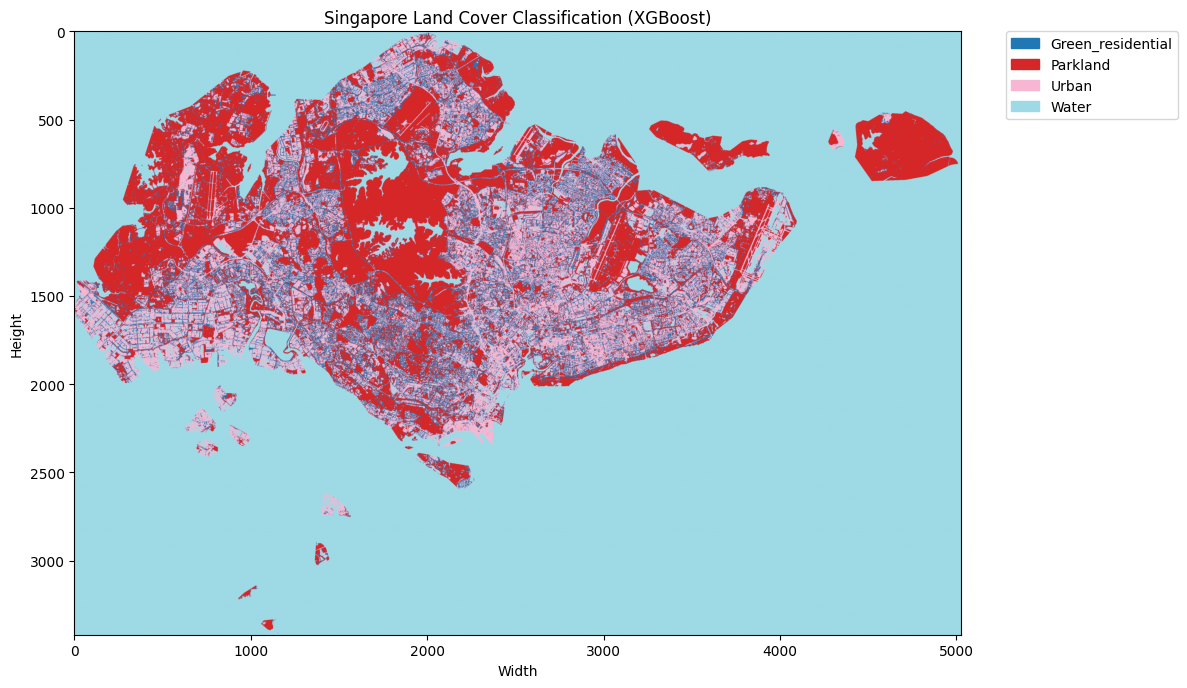

Classified Singapore image visualized.


In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

if singapore_src is not None and 'singapore_classified_image' in locals() and 'label_encoder' in locals():
    # Get the unique class labels from the predictions
    unique_classes_sg = np.unique(singapore_predictions_labels)

    # Create a color map for visualization
    # Assign a unique color to each class, ensuring consistency with previous visualizations if possible
    base_cmap_sg = plt.colormaps['tab20'] # Access colormap directly by name
    colors_sg = base_cmap_sg(np.linspace(0, 1, len(unique_classes_sg))) # Generate discrete colors
    cmap_sg = mcolors.ListedColormap(colors_sg)

    # Create a mapping from class names to integer labels for visualization purposes
    # Use the label_encoder's classes directly to ensure consistent integer mapping across images
    class_to_int_sg = {cls: i for i, cls in enumerate(label_encoder.classes_)}
    int_to_class_sg = {i: cls for i, cls in enumerate(label_encoder.classes_)}

    # Convert the string labels in the classified image to integers for the colormap
    singapore_classified_image_int = np.vectorize(class_to_int_sg.get)(singapore_classified_image)

    plt.figure(figsize=(12, 12))
    plt.imshow(singapore_classified_image_int, cmap=cmap_sg)
    plt.title('Singapore Land Cover Classification (XGBoost)')
    plt.xlabel('Width')
    plt.ylabel('Height')

    # Create a custom legend using mpatches.Patch
    patches_sg = [mpatches.Patch(color=colors_sg[class_to_int_sg[cls]], label=cls) for cls in unique_classes_sg]
    plt.legend(handles=patches_sg, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

    print("Classified Singapore image visualized.")
else:
    print("Cannot visualize classified Singapore image. Data or model components are missing.")

In [20]:
print("Mapping of integer values to land cover categories:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i}: {class_name}")

Mapping of integer values to land cover categories:
0: Green_residential
1: Parkland
2: Urban
3: Water


In [21]:
if singapore_src is not None:
    # Access the profile (metadata) from the singapore_src object
    singapore_profile = singapore_src.profile

    # Update the dtype to rasterio.uint8, as the classified image will have integer labels
    singapore_profile.update(dtype=rasterio.uint8)

    # Update the count to 1, as the classified image is a single-band raster
    singapore_profile.update(count=1)

    print("Singapore GeoTIFF profile successfully updated.")
    print(f"Updated dtype: {singapore_profile['dtype']}")
    print(f"Updated count: {singapore_profile['count']}")
else:
    print("Cannot retrieve or update profile, Singapore TIFF source is not available.")

Singapore GeoTIFF profile successfully updated.
Updated dtype: uint8
Updated count: 1


In [22]:
if singapore_src is not None and 'singapore_classified_image_int' in locals() and 'singapore_profile' in locals():
    output_path = '/content/drive/MyDrive/singapore_classified_image.tif'
    try:
        # Write the classified image to a new GeoTIFF file
        with rasterio.open(output_path, 'w', **singapore_profile) as dst:
            dst.write(singapore_classified_image_int.astype(singapore_profile['dtype']), 1)
        print(f"Classified Singapore image successfully exported to {output_path}")
    except Exception as e:
        print(f"Error exporting classified Singapore image: {e}")
else:
    print("Cannot export classified Singapore image. Required data or profile is missing.")

Classified Singapore image successfully exported to /content/drive/MyDrive/singapore_classified_image.tif
